Dataset loaded successfully!
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


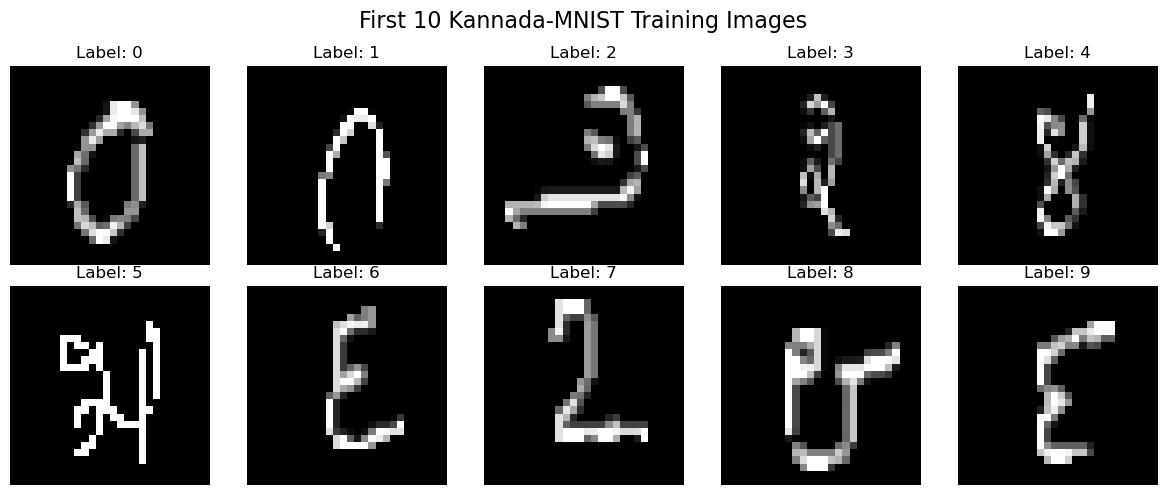

===== DATA INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, 0 to label
dtypes: uint8(785)
memory usage: 44.9 MB

===== DATA DESCRIPTION =====
             0        1        2        3        4             5  \
count  60000.0  60000.0  60000.0  60000.0  60000.0  60000.000000   
mean       0.0      0.0      0.0      0.0      0.0      0.008817   
std        0.0      0.0      0.0      0.0      0.0      1.474271   
min        0.0      0.0      0.0      0.0      0.0      0.000000   
25%        0.0      0.0      0.0      0.0      0.0      0.000000   
50%        0.0      0.0      0.0      0.0      0.0      0.000000   
75%        0.0      0.0      0.0      0.0      0.0      0.000000   
max        0.0      0.0      0.0      0.0      0.0    255.000000   

                  6             7             8             9  ...  \
count  60000.000000  60000.000000  60000.000000  60000.000000  ...   
mean       0.029467      0.037767      0.075933      0.1

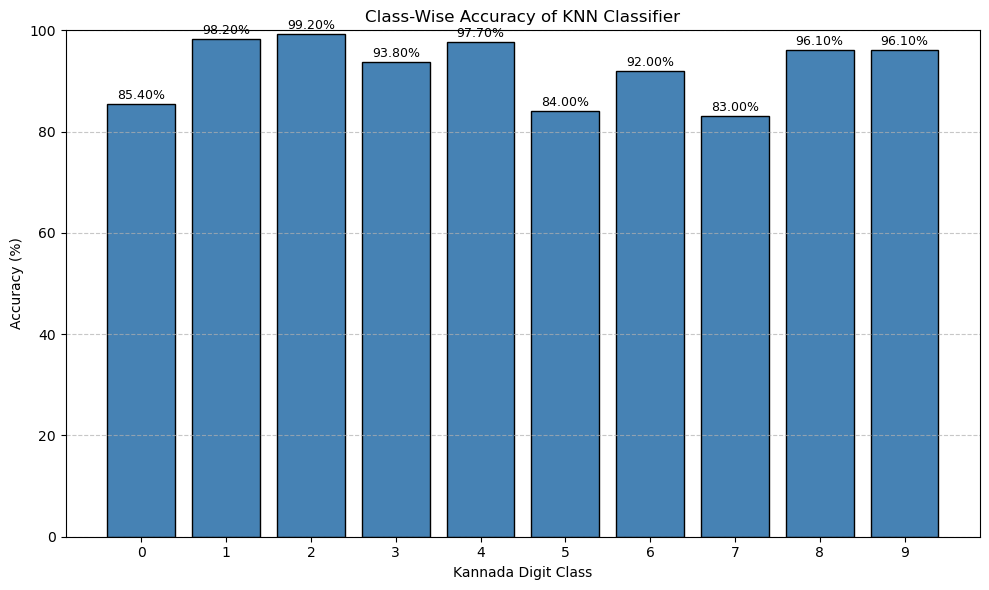

In [ ]:


import zipfile
import numpy as np
import io

zip_path = r"C:\Users\Maruthi B\Downloads\archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    X_train = np.load(io.BytesIO(
        z.read("Kannada_MNIST_datataset_paper/Kannada_MNIST_npz/Kannada_MNIST/X_kannada_MNIST_train.npz")
    ))["arr_0"]

    y_train = np.load(io.BytesIO(
        z.read("Kannada_MNIST_datataset_paper/Kannada_MNIST_npz/Kannada_MNIST/y_kannada_MNIST_train.npz")
    ))["arr_0"]

    X_test = np.load(io.BytesIO(
        z.read("Kannada_MNIST_datataset_paper/Kannada_MNIST_npz/Kannada_MNIST/X_kannada_MNIST_test.npz")
    ))["arr_0"]

    y_test = np.load(io.BytesIO(
        z.read("Kannada_MNIST_datataset_paper/Kannada_MNIST_npz/Kannada_MNIST/y_kannada_MNIST_test.npz")
    ))["arr_0"]

print("Dataset loaded successfully!")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
# ==========================================
# DISPLAY TOP 10 KANNADA-MNIST IMAGES
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("First 10 Kannada-MNIST Training Images", fontsize=16)
plt.tight_layout()
plt.show()
# ==========================================
# 2. DATA INFORMATION & DESCRIPTION
# ==========================================

import pandas as pd

data = pd.DataFrame(X_train.reshape(X_train.shape[0], -1))
data["label"] = y_train

print("===== DATA INFO =====")
data.info()

print("\n===== DATA DESCRIPTION =====")
print(data.describe())

print("\n===== DATASET SHAPE =====")
print(data.shape)

print("\n===== MISSING VALUES =====")
print(data.isnull().sum().sum())
# ==========================================
# 3. DATA PREPROCESSING
# ==========================================

# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flatten 28x28 images into 784 features
X_train_flat = X_train.reshape(X_train.shape[0], 784)
X_test_flat = X_test.reshape(X_test.shape[0], 784)

print("Preprocessing completed!")
print("X_train:", X_train_flat.shape)
print("X_test:", X_test_flat.shape)
print("Pixel range:", X_train_flat.min(), "to", X_train_flat.max())
# ==========================================
# 4. PRINCIPAL COMPONENT ANALYSIS (PCA)
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("PCA completed!")
print("Original features:", X_train_flat.shape[1])
print("Reduced features:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())
# ==========================================
# 5. KNN CLASSIFICATION
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_pca, y_train)

y_pred = knn.predict(X_test_pca)

print("KNN classification completed!")
# ==========================================
# 6. MODEL EVALUATION & ACCURACY
# ==========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)
print("KNN Accuracy (%):", accuracy * 100)
#==========================================
# 7. CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
# ==========================================
# GRAPH: CLASS-WISE ACCURACY
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

classes = np.unique(y_test)
class_accuracy = []

for digit in classes:
    total_images = np.sum(y_test == digit)
    correct_images = np.sum((y_test == digit) & (y_pred == digit))

    accuracy_percent = (correct_images / total_images) * 100
    class_accuracy.append(accuracy_percent)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    classes,
    class_accuracy,
    color="steelblue",
    edgecolor="black"
)

plt.xlabel("Kannada Digit Class")
plt.ylabel("Accuracy (%)")
plt.title("Class-Wise Accuracy of KNN Classifier")
plt.ylim(0, 100)
plt.xticks(classes)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Display accuracy values above bars
for bar, value in zip(bars, class_accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()